<a href="https://colab.research.google.com/github/hsmu-jeongeun/health-infomatics/blob/main/12_Epidemiology_Spatial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 보건 역학과 데이터 웨어하우스 : 공간 데이터 시각화

## 학습 목표
- 공간 데이터(지역별 감염병 발생 통계)의 구조를 이해할 수 있다
- Folium으로 대화형 지도 히트맵을 생성할 수 있다
- Matplotlib으로 지역별 감염병 발생 현황을 시각화할 수 있다

---

## 오늘의 핵심 개념: 데이터 웨어하우스와 보건 빅데이터

> 여러 병원·보건소의 데이터가 각각 흩어져 있다면 전국 감염병 추세를 파악하기 어려움. 데이터 웨어하우스는 이 모든 데이터를 한곳에 모아 분석에 최적화된 창고

### 데이터 웨어하우스(DW)와 공중보건
- **건강보험심사평가원(HIRA):** 전국 모든 진료 청구 데이터를 보유한 국내 최대 의료 DW
- **질병관리청 감염병 감시 시스템:** 전국 감염병 발생 데이터를 실시간 집계·시각화
- **활용 사례:**
  - 코로나19 지역별 확산 추이 분석
  - 독감 유행 지역 조기 예측
  - 지역별 만성질환 유병률 지도

### 공간 데이터 분석의 중요성
- 감염병은 **지역적 패턴**을 가짐 (클러스터, 핫스팟)
- 공간 분석으로 의료 취약 지역 파악 → 의료 자원 배분 최적화

In [1]:
!sudo apt-get install -y fonts-nanum

!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print('기본 라이브러리 로드 완료!')

기본 라이브러리 로드 완료!


## 가상의 지역별 감염병 발생 데이터 생성

In [3]:
# 한국 17개 시도별 가상 감염병 발생 통계
np.random.seed(42)

# 주요 좌표 (위도, 경도)
regions = {
    '서울':   {'lat': 37.5665, 'lon': 126.9780, 'pop': 9.4},
    '경기':   {'lat': 37.4138, 'lon': 127.5183, 'pop': 13.5},
    '인천':   {'lat': 37.4563, 'lon': 126.7052, 'pop': 3.0},
    '부산':   {'lat': 35.1796, 'lon': 129.0756, 'pop': 3.4},
    '대구':   {'lat': 35.8714, 'lon': 128.6014, 'pop': 2.4},
    '광주':   {'lat': 35.1595, 'lon': 126.8526, 'pop': 1.5},
    '대전':   {'lat': 36.3504, 'lon': 127.3845, 'pop': 1.5},
    '울산':   {'lat': 35.5384, 'lon': 129.3114, 'pop': 1.1},
    '세종':   {'lat': 36.4801, 'lon': 127.2890, 'pop': 0.4},
    '강원':   {'lat': 37.8228, 'lon': 128.1555, 'pop': 1.5},
    '충북':   {'lat': 36.8000, 'lon': 127.7000, 'pop': 1.6},
    '충남':   {'lat': 36.5184, 'lon': 126.8000, 'pop': 2.1},
    '전북':   {'lat': 35.7175, 'lon': 127.1530, 'pop': 1.8},
    '전남':   {'lat': 34.8679, 'lon': 126.9910, 'pop': 1.8},
    '경북':   {'lat': 36.4919, 'lon': 128.8889, 'pop': 2.6},
    '경남':   {'lat': 35.4606, 'lon': 128.2132, 'pop': 3.3},
    '제주':   {'lat': 33.4890, 'lon': 126.4983, 'pop': 0.7},
}

# 감염병 발생 건수 (인구 비례 + 랜덤 변동)
for region, info in regions.items():
    base = info['pop'] * np.random.uniform(80, 180)
    regions[region]['cases'] = int(base)

df_epi = pd.DataFrame([
    {
        '지역': name,
        '위도': info['lat'],
        '경도': info['lon'],
        '인구_백만': info['pop'],
        '발생건수': info['cases'],
        '인구10만당발생률': round(info['cases'] / info['pop'] / 10, 1)
    }
    for name, info in regions.items()
]).sort_values('발생건수', ascending=False).reset_index(drop=True)

print('지역별 감염병 발생 데이터 생성 완료!')
print(df_epi)

지역별 감염병 발생 데이터 생성 완료!
    지역       위도        경도  인구_백만  발생건수  인구10만당발생률
0   경기  37.4138  127.5183   13.5  2363       17.5
1   서울  37.5665  126.9780    9.4  1104       11.7
2   부산  35.1796  129.0756    3.4   475       14.0
3   인천  37.4563  126.7052    3.0   459       15.3
4   충남  36.5184  126.8000    2.1   371       17.7
5   경남  35.4606  128.2132    3.3   324        9.8
6   전북  35.7175  127.1530    1.8   293       16.3
7   경북  36.4919  128.8889    2.6   255        9.8
8   대구  35.8714  128.6014    2.4   229        9.5
9   강원  37.8228  128.1555    1.5   226       15.1
10  울산  35.5384  129.3114    1.1   183       16.6
11  전남  34.8679  126.9910    1.8   182       10.1
12  광주  35.1595  126.8526    1.5   143        9.5
13  충북  36.8000  127.7000    1.6   131        8.2
14  대전  36.3504  127.3845    1.5   128        8.5
15  제주  33.4890  126.4983    0.7    77       11.0
16  세종  36.4801  127.2890    0.4    56       14.0


## 발생 건수 상위 지역 막대 그래프

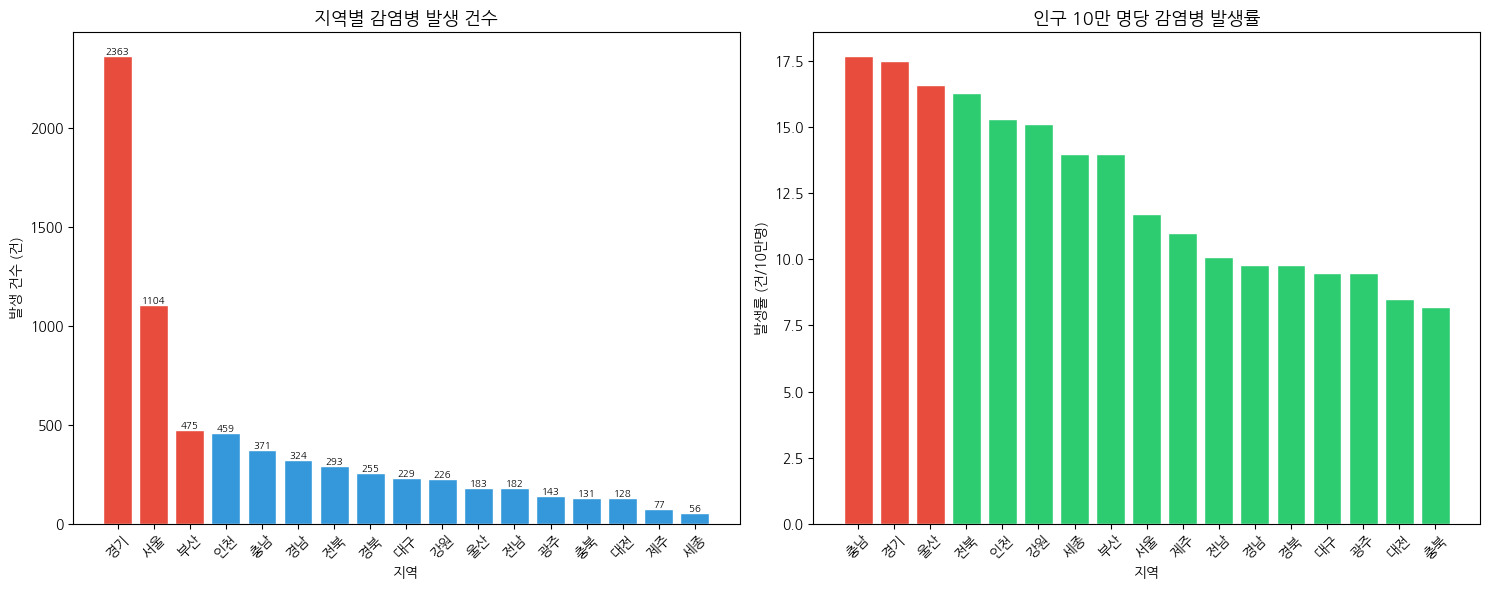

발생 건수 1위 지역: 경기 (2363건)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 발생 건수
colors_1 = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(df_epi))]
bars = axes[0].bar(df_epi['지역'], df_epi['발생건수'], color=colors_1, edgecolor='white')
axes[0].set_title('지역별 감염병 발생 건수', fontsize=13)
axes[0].set_xlabel('지역')
axes[0].set_ylabel('발생 건수 (건)')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, df_epi['발생건수']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=7)

# 인구 10만 명당 발생률
df_rate = df_epi.sort_values('인구10만당발생률', ascending=False)
colors_2 = ['#e74c3c' if i < 3 else '#2ecc71' for i in range(len(df_rate))]
bars2 = axes[1].bar(df_rate['지역'], df_rate['인구10만당발생률'], color=colors_2, edgecolor='white')
axes[1].set_title('인구 10만 명당 감염병 발생률', fontsize=13)
axes[1].set_xlabel('지역')
axes[1].set_ylabel('발생률 (건/10만명)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

most_cases_region = df_epi.iloc[0]['지역']
print(f'발생 건수 1위 지역: {most_cases_region} ({df_epi.iloc[0]["발생건수"]}건)')

## 지도 시각화 (Folium)

> Folium은 Python에서 대화형 지도(Leaflet.js 기반)를 생성하는 라이브러리

In [5]:
try:
    import folium
    from folium.plugins import HeatMap
    FOLIUM_AVAILABLE = True
    print(f'Folium 버전: {folium.__version__}')
except ImportError:
    FOLIUM_AVAILABLE = False
    print('Folium 미설치. !pip install folium 후 재실행하세요.')

Folium 버전: 0.20.0


In [6]:
if FOLIUM_AVAILABLE:
    # 한국 중심 지도 생성
    m = folium.Map(location=[36.5, 127.5], zoom_start=7, tiles='CartoDB positron')

    # 히트맵 레이어
    heat_data = [[row['위도'], row['경도'], row['발생건수']]
                 for _, row in df_epi.iterrows()]
    HeatMap(heat_data, radius=40, blur=20, min_opacity=0.4).add_to(m)

    # 지역별 원형 마커
    for _, row in df_epi.iterrows():
        folium.CircleMarker(
            location=[row['위도'], row['경도']],
            radius=max(5, row['발생건수'] / 200),
            color='#e74c3c',
            fill=True,
            fill_opacity=0.7,
            tooltip=f"{row['지역']}: {row['발생건수']}건"
        ).add_to(m)

    # 상위 3개 지역 레이블
    for _, row in df_epi.head(3).iterrows():
        folium.Marker(
            location=[row['위도'], row['경도']],
            popup=f"{row['지역']}: {row['발생건수']}건",
            icon=folium.Icon(color='red', icon='info-sign')
        ).add_to(m)

    m.save('korea_heatmap.html')
    print('지도 저장 완료: korea_heatmap.html')
    print('Colab에서는 아래 셀로 지도를 표시합니다.')
    display(m)
else:
    print('Folium 없이 Matplotlib로 대체 시각화를 표시합니다.')

지도 저장 완료: korea_heatmap.html
Colab에서는 아래 셀로 지도를 표시합니다.


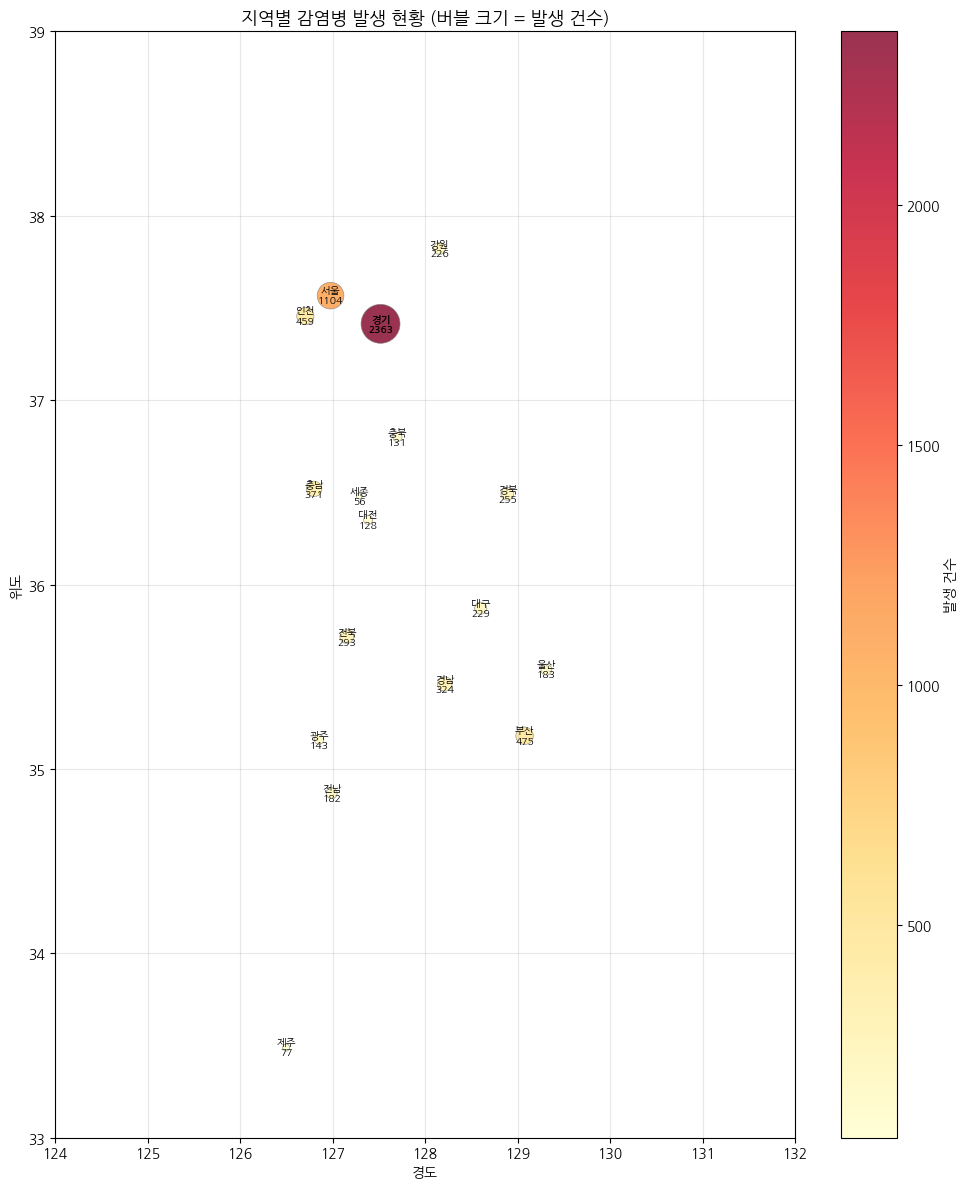

In [7]:
# Folium 없이도 확인 가능한 버블 차트 (크기 = 발생 건수)
fig, ax = plt.subplots(figsize=(10, 12))

sc = ax.scatter(
    df_epi['경도'], df_epi['위도'],
    s=[c/3 for c in df_epi['발생건수']],
    c=df_epi['발생건수'],
    cmap='YlOrRd',
    alpha=0.8,
    edgecolors='gray',
    linewidths=0.5
)

for _, row in df_epi.iterrows():
    ax.annotate(f"{row['지역']}\n{row['발생건수']}",
                xy=(row['경도'], row['위도']),
                ha='center', va='center', fontsize=7.5,
                fontweight='bold' if row['발생건수'] == df_epi['발생건수'].max() else 'normal')

plt.colorbar(sc, ax=ax, label='발생 건수')
ax.set_title('지역별 감염병 발생 현황 (버블 크기 = 발생 건수)', fontsize=13)
ax.set_xlabel('경도')
ax.set_ylabel('위도')
ax.set_xlim(124, 132)
ax.set_ylim(33, 39)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Canvas 퀴즈 안내

아래 코드 셀을 실행하여 나온 **단어**를 Canvas 퀴즈의 정답으로 제출하세요.

**문제:** 코드 실행 결과, 감염병 발생 환자 수가 **가장 많은 지역**의 이름은?

In [ ]:
# [실습] 아래 코드를 실행하여 나온 결과를 Canvas 퀴즈의 정답으로 제출
canvas_answer = df_epi.iloc[0]['지역']
print(f'Answer: {canvas_answer}')